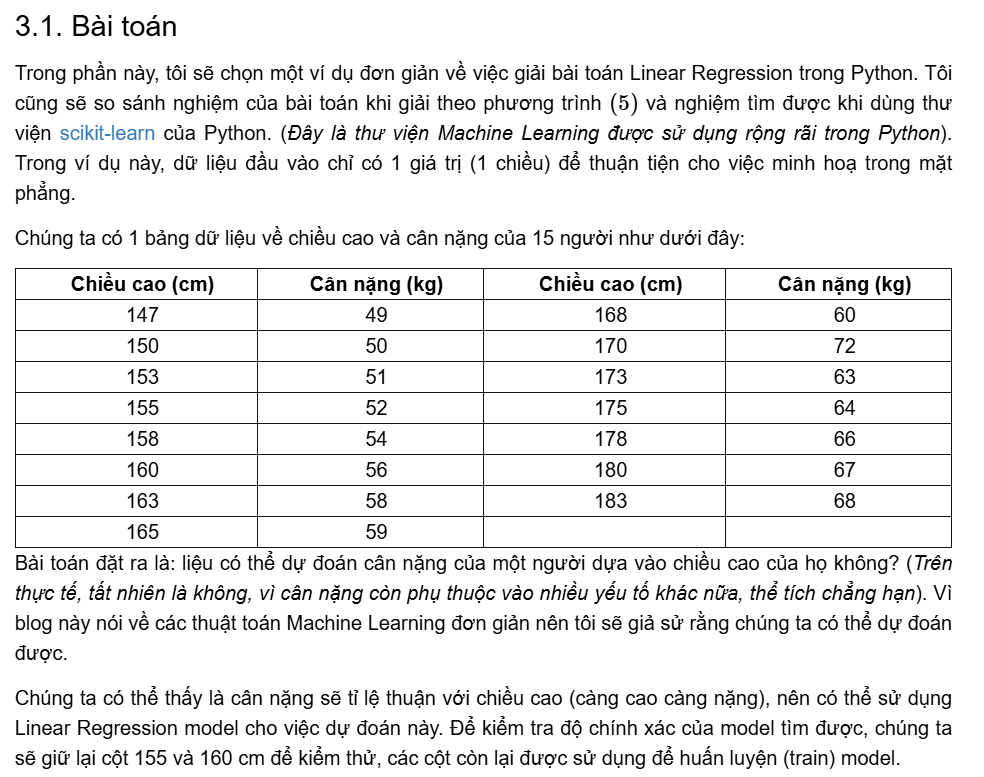

Thư viện


In [1]:
from __future__ import division, print_function, unicode_literals
import numpy as np 
import matplotlib.pyplot as plt

1. Giới thiệu: hồi quy tuyến tính là một thuật toán thuộc nhóm Học có giám sát (Supervised Learning) Trong mô hình này, mối quan hệ giữa đầu vào (features) và đầu ra (target) được mô tả bởi một hàm tuyến tính. Với mục tiêu dự đoán giá trị của đầu ra dựa trên một vector đặc trưng đầu vào
.

2. Mô hình toán học: Giả sử có một điểm dữ liệu x là vector đặc trưng. Mô hình tuyến tính có dạng đơn giản: 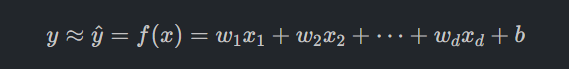
trong đó w là vector hệ số(trọng số), b là số hạng tự do(bias)

3. Hàm mất mát: Mục tiêu tìm w sao cho sai số giữa giá trị thực y và giá trị dự đoán y^ là nhỏ nhất: 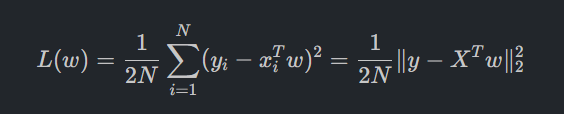

Để tìm w tối ưu, ta giải phương trình đạo hàm hàm mất mát bằng 0: 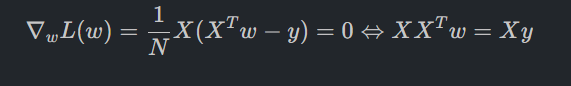

Nghiệm của bài toán có thể được xác định dựa vào giả nghịch đảo (pseudo inverse):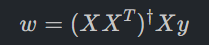

Ví dụ python giải quyết bài toán

Dữ liệu

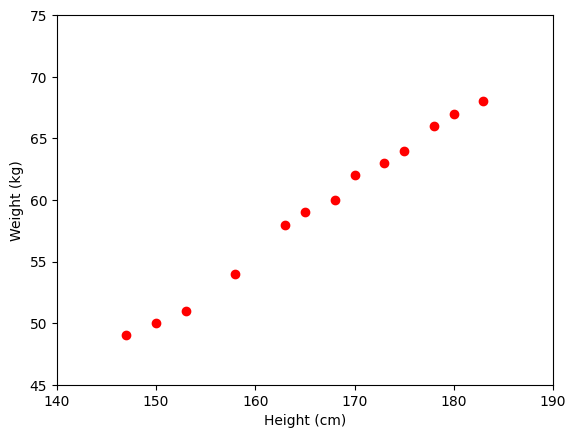

In [2]:
# height (cm)
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T
# weight (kg)
y = np.array([[ 49, 50, 51,  54, 58, 59, 60, 62, 63, 64, 66, 67, 68]]).T
# Visualize data 
plt.plot(X, y, 'ro')
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

w =  [[-33.73541021]
 [  0.55920496]]


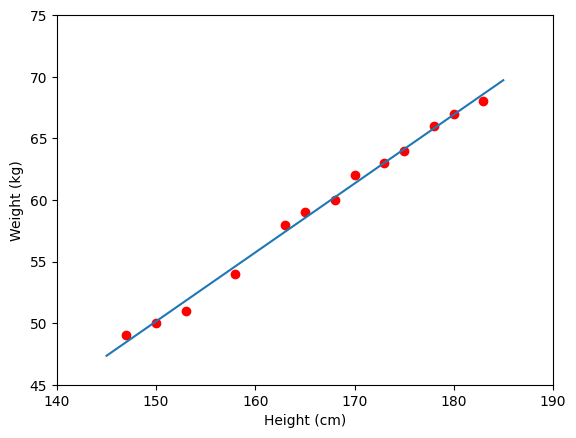

Predict weight of person with height 155 cm: 52.94 (kg), real number: 52 (kg)
Predict weight of person with height 160 cm: 55.74 (kg), real number: 56 (kg)


In [4]:
# Building Xbar 
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis = 1)

# Calculating weights of the fitting line 
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w = np.dot(np.linalg.pinv(A), b)
print('w = ', w)
# Preparing the fitting line 
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(145, 185, 2)
y0 = w_0 + w_1*x0

# Drawing the fitting line 
plt.plot(X.T, y.T, 'ro')     # data 
plt.plot(x0, y0)               # the fitting line
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()
y1 = w_1*155 + w_0
y2 = w_1*160 + w_0

print( u'Predict weight of person with height 155 cm: %.2f (kg), real number: 52 (kg)'  %(y1) )
print( u'Predict weight of person with height 160 cm: %.2f (kg), real number: 56 (kg)'  %(y2) )

Scikit-learn thư viện

In [5]:
from sklearn import datasets, linear_model

# fit the model by Linear Regression
regr = linear_model.LinearRegression(fit_intercept=False) # fit_intercept = False for calculating the bias
regr.fit(Xbar, y)

# Compare two results
print( 'Solution found by scikit-learn  : ', regr.coef_ )
print( 'Solution found by (5): ', w.T)

Solution found by scikit-learn  :  [[-33.73541021   0.55920496]]
Solution found by (5):  [[-33.73541021   0.55920496]]
